In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
#pip install torch==2.9.1 torchvision==0.24.1 torchaudio==2.9.1 --index-url https://download.pytorch.org/whl/cu126
import torch
print(torch.cuda.is_available())

True


In [3]:
from src.utils import *
import matplotlib.pyplot as plt
import skimage as ski
from prettytable import PrettyTable
train_x, train_y = get_dataset(DATASETS.TRAIN.value)
val_x, val_y = get_dataset(DATASETS.VALIDATION.value)
test_x, test_y = get_dataset(DATASETS.TEST.value)

In [4]:
from src.utils import read_create_seg_map
_, data_y = read_create_seg_map(train_x[0], train_y[0])

In [5]:
def print_average_overlay(*args):
    datasets_n = len(args) - 1
    dataset_names = args[-1]
    table = PrettyTable()
    table.field_names = ["Dataset", "Minimum overlay", "Maximum overlay", "Median overlay", "Average overlay"]
    for i in range(0, datasets_n, 2):
        dataset_x = args[i]
        dataset_y = args[i+1]
        avarages = []
        for sample_x, sample_y in zip(dataset_x, dataset_y):
            _, seg_map = read_create_seg_map(sample_x, sample_y)
            avarages.append(seg_map.sum()/np.multiply(*seg_map.shape))
        table.add_row([
            dataset_names[i//2],
            round(min(avarages)*100, 2),
            round(max(avarages)*100, 2),
            round(np.median(avarages)*100, 2),
            round(np.average(avarages)*100, 2)])
    print(table)
print_average_overlay(train_x, train_y, val_x, val_y, test_x, test_y, ["TRAIN", "VALIDATION", "TEST"])

+------------+-----------------+-----------------+----------------+-----------------+
|  Dataset   | Minimum overlay | Maximum overlay | Median overlay | Average overlay |
+------------+-----------------+-----------------+----------------+-----------------+
|   TRAIN    |       0.34      |      10.89      |      1.81      |       2.16      |
| VALIDATION |       0.0       |       6.86      |      1.69      |       2.02      |
|    TEST    |       0.36      |       5.91      |      1.62      |       1.98      |
+------------+-----------------+-----------------+----------------+-----------------+


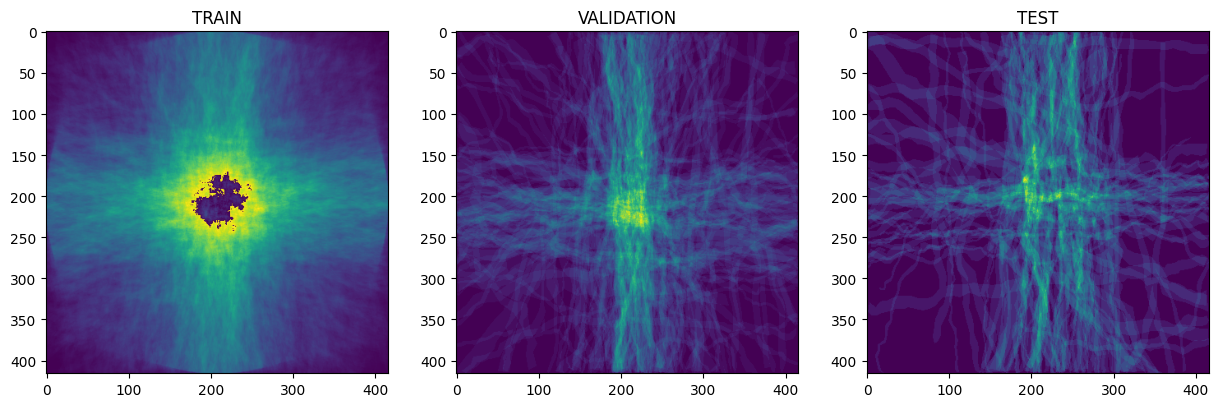

In [6]:
def plot_coverage(*args):#assuming uniform size
    datasets_n = len(args) - 1
    dataset_names = args[-1]
    plt.rcParams["figure.figsize"] = (15,5)
    for i in range(0, datasets_n, 2):
        dataset_x = args[i]
        dataset_y = args[i+1]
        seg_sum = None
        for sample_x, sample_y in zip(dataset_x, dataset_y):
            _, seg_map = read_create_seg_map(sample_x, sample_y)
            if seg_sum is None:
                seg_sum = seg_map
            else:
                seg_sum += seg_map
        seg_sum = seg_sum / seg_sum.max()
        plt.subplot(1, datasets_n//2, i//2+1).set_title(dataset_names[i//2])
        plt.imshow(seg_sum)
plot_coverage(train_x, train_y, val_x, val_y, test_x, test_y, ["TRAIN", "VALIDATION", "TEST"])

In [7]:
def print_component_analysis(*args):
    datasets_n = len(args)-1
    dataset_names = args[-1]
    table = PrettyTable()
    table.field_names = ["Dataset", "Minimum component count", "Maximum component count", "Median component count", "Average component count"]
    for i in range(0, datasets_n, 2):
        dataset_x = args[i]
        dataset_y = args[i+1]
        cc_count = []

        for sample_x, sample_y in zip(dataset_x, dataset_y):
            _, seg_map = read_create_seg_map(sample_x, sample_y)

            cc_count_n, _ = cv2.connectedComponents(seg_map)
            cc_count.append(cc_count_n - 1)
        table.add_row([dataset_names[i//2],
            min(cc_count), max(cc_count),
            np.median(cc_count), round( np.average(cc_count), 2)])
    print(table)
print_component_analysis(train_x, train_y, val_x, val_y, test_x, test_y, ["TRAIN", "VALIDATION", "TEST"])


+------------+-------------------------+-------------------------+------------------------+-------------------------+
|  Dataset   | Minimum component count | Maximum component count | Median component count | Average component count |
+------------+-------------------------+-------------------------+------------------------+-------------------------+
|   TRAIN    |            1            |            11           |          1.0           |           1.25          |
| VALIDATION |            0            |            6            |          1.0           |           1.18          |
|    TEST    |            1            |            5            |          1.0           |           1.21          |
+------------+-------------------------+-------------------------+------------------------+-------------------------+


- test set does not have empty cases
- average and median are similar
- max component is redundant to consider, as further research degree of instance seperation can be measured, but that would be mostly for edge cases

+------------+-------------------+-------------------+------------------+-------------------+
|  Dataset   | Minimum max_width | Maximum max_width | Median max_width | Average max_width |
+------------+-------------------+-------------------+------------------+-------------------+
|   TRAIN    |        1.41       |       42.05       |       5.66       |        6.44       |
| VALIDATION |        0.0        |        26.0       |       5.1        |        6.26       |
|    TEST    |        2.0        |        17.0       |       5.74       |        6.08       |
+------------+-------------------+-------------------+------------------+-------------------+
+------------+-------------------+-------------------+------------------+-------------------+
|  Dataset   | Minimum avg_width | Maximum avg_width | Median avg_width | Average avg_width |
+------------+-------------------+-------------------+------------------+-------------------+
|   TRAIN    |        1.01       |       11.43       |      

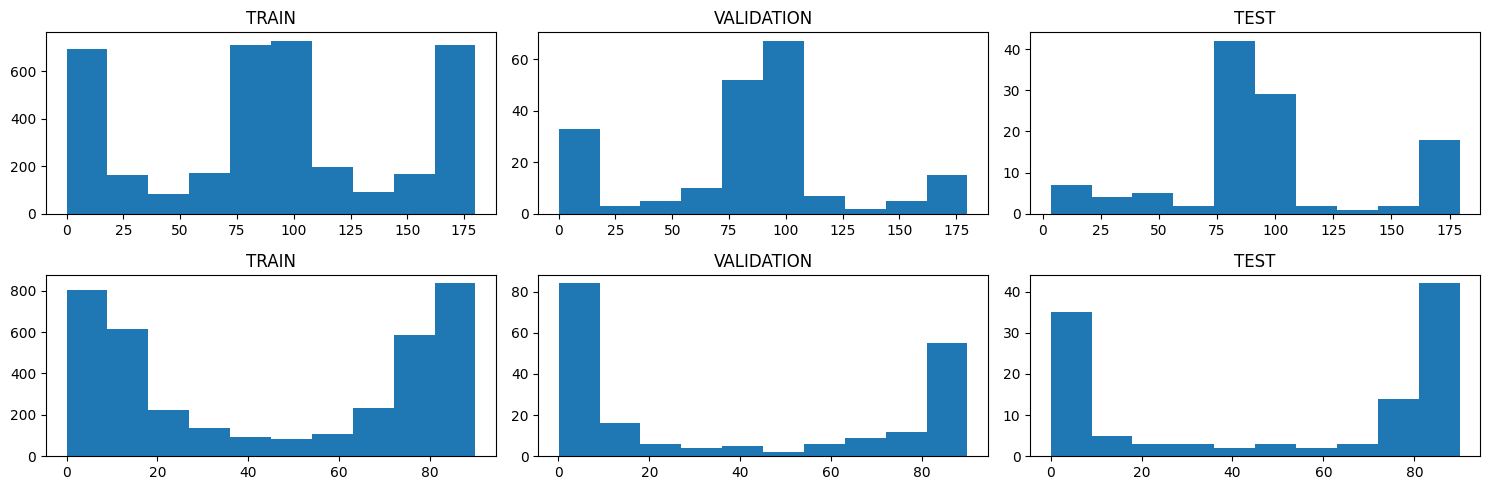

In [ ]:
def print_skeleton_analysis(*args):
    datasets_n = len(args) - 1
    dataset_names = args[-1]
    plt.rcParams["figure.figsize"] = (15,5)

    table_max_width = PrettyTable()
    table_avg_width = PrettyTable()
    table_linearity = PrettyTable()
    table_max_width.field_names = ["Dataset", "Minimum max_width", "Maximum max_width", "Median max_width", "Average max_width"]
    table_avg_width.field_names = ["Dataset", "Minimum avg_width", "Maximum avg_width", "Median avg_width", "Average avg_width"]
    table_linearity.field_names = ["Dataset", "Minimum linearity", "Maximum linearity", "Median linearity", "Average linearity"]
    def add_stats_to_table(table, variable):
        if len(variable) > 0:
            table.add_row([dataset_names[i//2],
                round(min(variable), 2), round(max(variable), 2),
                round(np.median(variable), 2), round(np.average(variable), 2)])

    for i in range(0, datasets_n, 2):
        dataset_x = args[i]
        dataset_y = args[i+1]
        instance_max_width = []
        instance_avg_width = []
        instance_angle_180 = []
        instance_angle_90 = []
        instance_linearity = []

        for sample_x, sample_y in zip(dataset_x, dataset_y):
            _, seg_map = read_create_seg_map(sample_x, sample_y)

            out_skeleton, distance = ski.morphology.medial_axis(seg_map, return_distance=True)
            instance_max_width.append(np.max(distance))
            if np.sum(distance[seg_map>0]) > 0:
                instance_avg_width.append(np.average(distance[seg_map>0]))

            ys, xs = np.where(out_skeleton > 0)
            points = np.column_stack((xs, ys))
            if len(points) > 0:
                mean, eigvec = cv2.PCACompute(points.astype(np.float32), mean=None)
                vx, vy = eigvec[0]
                angle_180 = (np.degrees(np.arctan2(vy, vx)) + 180) % 180
                angle_90 = (np.degrees(np.arctan2(vy, vx)) + 90) % 90

                instance_angle_180.append(angle_180)
                instance_angle_90.append(angle_90)

                p0 = mean[0]
                v = eigvec[0]
                diff = points - p0
                distances = np.abs(diff[:,0] * v[1] - diff[:,1] * v[0])
                instance_linearity.append(np.average(distances))

        plt.subplot(2, datasets_n//2, i//2 + 1).set_title(dataset_names[i//2])
        instance_angle_180.sort()
        plt.hist(instance_angle_180, 10)
        instance_angle_90.sort()
        plt.subplot(2, datasets_n//2, i//2 + 4).set_title(dataset_names[i//2])
        plt.hist(instance_angle_90, 10)

        add_stats_to_table(table_max_width, instance_max_width)
        add_stats_to_table(table_avg_width, instance_avg_width)
        add_stats_to_table(table_linearity, instance_linearity)


    print(table_max_width)
    print(table_avg_width)
    print(table_linearity)
    print("Angle histograms")
    plt.tight_layout()

print_skeleton_analysis(train_x, train_y, val_x, val_y, test_x, test_y, ["TRAIN", "VALIDATION", "TEST"])


- based on medial axis distance, it should be taken into account in case of dimensionality reduction
- skeleton analysis of angle confirms overlay analysis where there is low angle variation and data augmantation via rotation can be beneficial

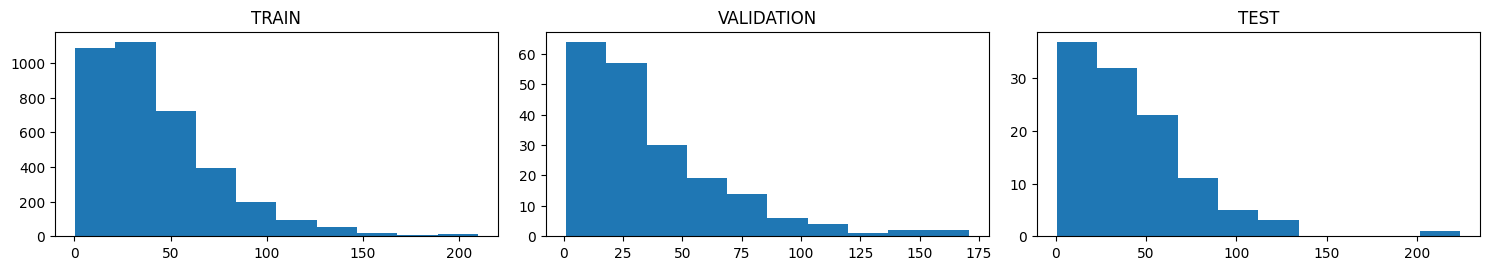

In [ ]:
def print_translation_analysis(*args):
    datasets_n = len(args) - 1
    dataset_names = args[-1]
    plt.rcParams["figure.figsize"] = (15,5)
    for i in range(0, datasets_n, 2):
        dataset_x = args[i]
        dataset_y = args[i+1]
        translations = []
        for sample_x, sample_y in zip(dataset_x, dataset_y):
            _, seg_map = read_create_seg_map(sample_x, sample_y)
            w, h = np.shape(seg_map)[:2]
            ys, xs = np.where(seg_map > 0)
            points = np.column_stack((xs, ys))
            if len(points) < 2:
                continue
            mean, _ = cv2.PCACompute(points.astype(np.float32), mean=None)
            p0 = mean[0]
            d = np.sqrt((p0[0] - w/2)**2 + (p0[1] - h/2)**2)
            translations.append(d)
        plt.subplot(2, datasets_n//2, i//2 + 1).set_title(dataset_names[i//2])
        translations.sort()
        plt.hist(translations, 10)
    plt.tight_layout()
print_translation_analysis(train_x, train_y, val_x, val_y, test_x, test_y, ["TRAIN", "VALIDATION", "TEST"])

with this close corelation, translations can be ommited, or some small jitter added